In [2]:

from simbanator.analysis import HDF5BuildHistory
from simbanator.io.simba import Simulation
from matplotlib import pyplot as plt

# Load your simulation (use the name you configured)
sim = Simulation("cis100")  # Replace XX with your snapshot number
cs = sim.load_catalog(snap=151)
progen = False

yt : [INFO     ] 2026-03-19 10:26:11,171 Opening /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_151.hdf5
yt : [INFO     ] 2026-03-19 10:26:11,244 Found 464043 halos
yt : [INFO     ] 2026-03-19 10:26:11,307 Found 55609 galaxies


In [3]:
if progen:
    from simbanator.analysis import caesar_read_progen
    ids = [g.GroupID for g in cs.galaxies]
    caesar_read_progen(ids, 'progenitors_most_mass.fits', range(44, 151), sim, output_dir=None)

In [44]:
hist = HDF5BuildHistory(sim, cs)
from astropy.io import fits
with fits.open(hist.progen_file) as hdul:
    valid_ids = hdul[1].data['GroupID']
    
hist.get_history_indx(valid_ids, 150, 44)

z, props = hist.get_property_history({
    'galaxy_data': ['masses.stellar', 'sfr', 'pos', 'GroupID'],
    'halo_data':   ['masses.total'],
}, verbose=1)

hist.save_history_to_hdf5('full_simba100_histories_z0_nall.hdf5')
# Interpolate stellar mass at z=0.5

  snap 150: /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_150.hdf5
  snap 149: /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_149.hdf5
  snap 148: /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_148.hdf5
  snap 147: /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_147.hdf5
  snap 146: /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_146.hdf5
  snap 145: /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_145.hdf5
  snap 144: /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_144.hdf5
  snap 143: /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_143.hdf5
  snap 142: /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_142.hdf5
  snap 141: /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_141.hdf5
  snap 140: /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_140.hdf5
  snap 139: /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_139.hdf5
  snap 138: /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_138.hdf5
  snap 137: /mnt/home/share/simbas/SIMBA_100/Groups/m100n1024_137.hdf5
  snap

'/mnt/home/glorenzon/output/caesar_sfh/full_simba100_histories_z0_nall.hdf5'

KeyboardInterrupt: 

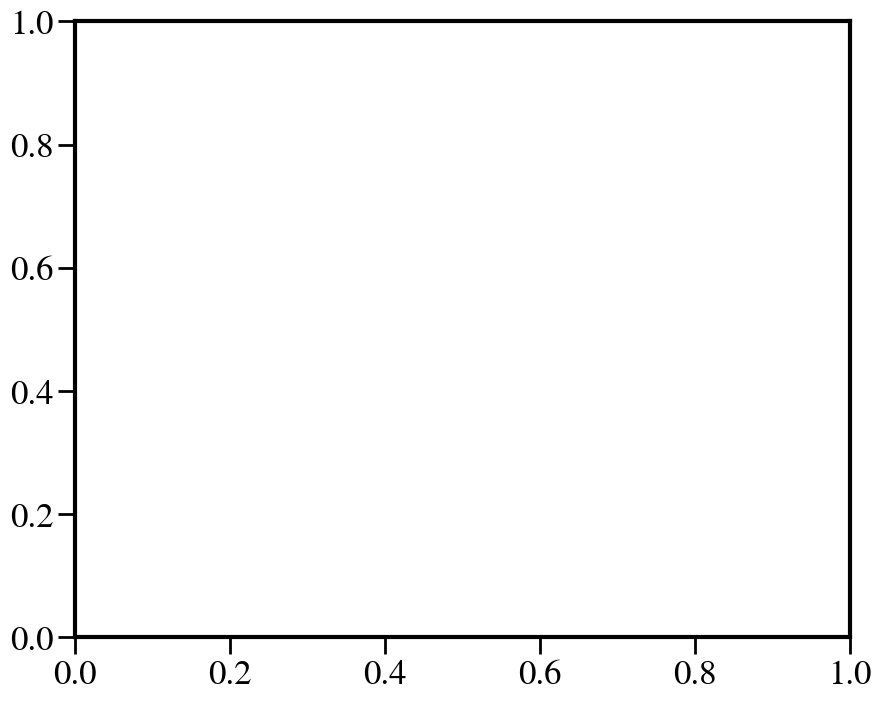

In [5]:
#check positions make sense
plt.plot(props['pos'][:, :, 0], props['pos'][:, :, 1])

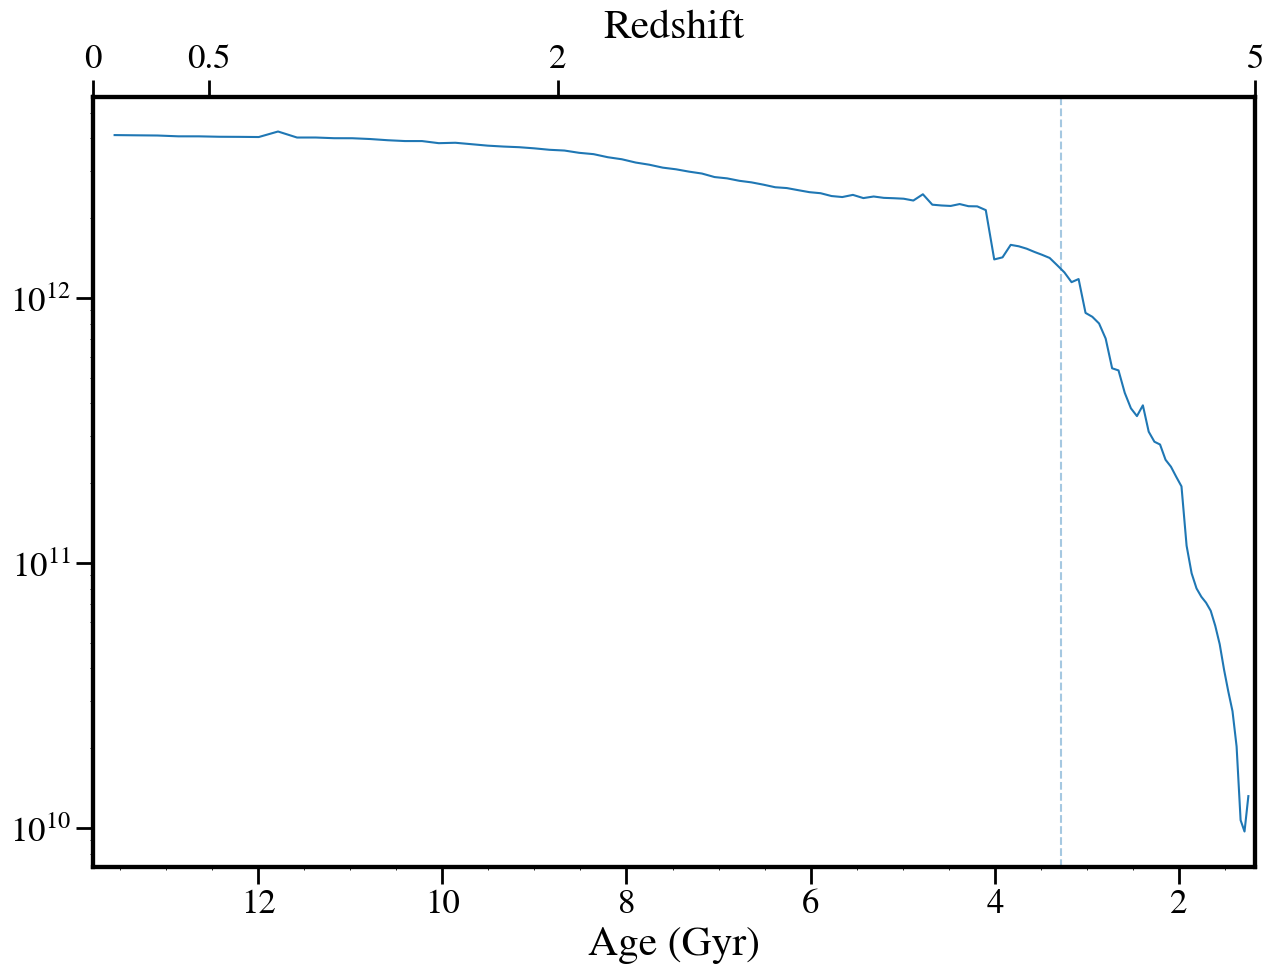

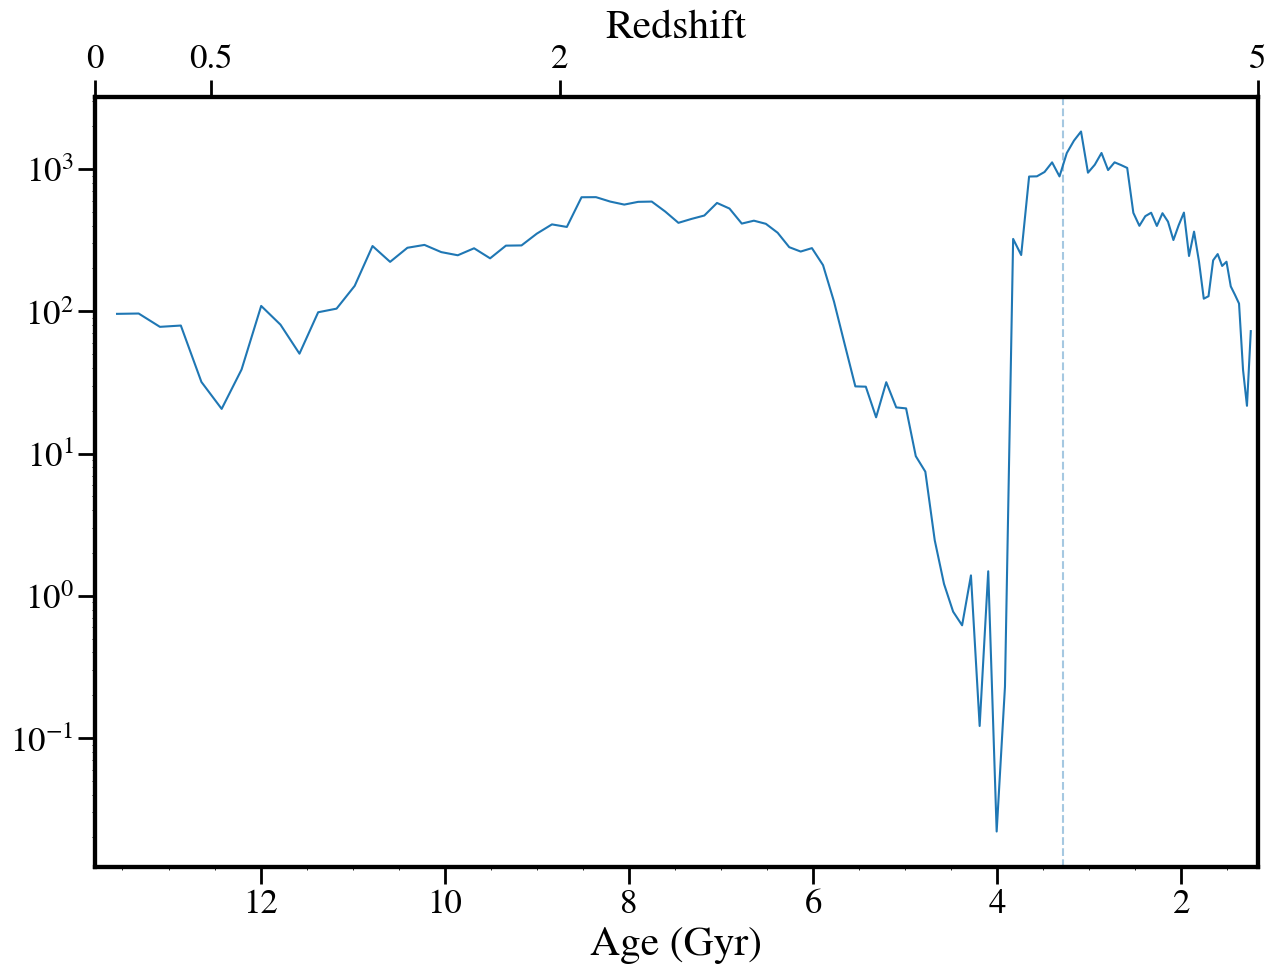

In [ ]:
#check interpolation and history
hist.propr_from_z('masses.stellar', 2)
hist.plot_history(zlist=[0, 0.5, 2, 5], propr='masses.stellar', outname='stellar_mass_history.png', indx=1)
plt.yscale('log')


#check interpolation and history
hist.propr_from_z('sfr', 2)
hist.plot_history(zlist=[0, 0.5, 2, 5], propr='sfr', outname='sSFsfrH.png', indx=1)
plt.yscale('log')

In [11]:
# Run find_quenching_times on all sources in the saved HDF5 file
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from simbanator.analysis.quenching import find_quenching_times, load_quenching_events
from astropy.cosmology import Planck15

h5_path = '/mnt/home/glorenzon/output/caesar_sfh/full_simba100_histories_z0_nall.hdf5'  # update if needed
# Use a clean absolute path (TOPCAT-friendly, no gvfs prefix needed in TOPCAT)
fits_out = '/mnt/home/glorenzon/output/quenching_times/quenching_times.fits'
os.makedirs(os.path.dirname(fits_out), exist_ok=True)

# Optional: reset output file for a clean batch run
if os.path.exists(fits_out):
    os.remove(fits_out)

with h5py.File(h5_path, 'r') as f:
    galaxy_ids = f['metadata/galaxy_ids'][:]
    sfr = f['properties/sfr'][:]
    mass = f['properties/masses.stellar'][:]
    redshift = f['redshift/Redshift'][:]

# Convert redshift to cosmic time (Gyr)
cosmo = Planck15
cosmic_time = cosmo.age(redshift).value  # Gyr

# Calculate sSFR (SFR / Mstar) for all galaxies
ssfr = sfr / mass  # shape: (n_snaps, n_gal)

# Run find_quenching_times for each galaxy
results = []
n_gal = ssfr.shape[1] if ssfr.ndim == 2 else 1
for gal in range(n_gal):
    print(f"Processing galaxy index {gal} (ID={galaxy_ids[gal] if ssfr.ndim == 2 else galaxy_ids})...")
    # if gal > 30:
    #     print('Limiting to first 31 galaxies for testing...')
    #     break
    ssfr_gal = ssfr[:, gal] if ssfr.ndim == 2 else ssfr

    # Mask out invalid (nan or non-positive) values
    valid = np.isfinite(ssfr_gal) & (ssfr_gal > 0)
    if np.sum(valid) < 5:
        results.append(None)
        continue

    tarr = cosmic_time[valid] * 1e9  # convert Gyr to yr
    ssfr_valid = ssfr_gal[valid]

    # Sort by cosmic time and remove duplicates
    sort_idx = np.argsort(tarr)
    tarr_sorted = tarr[sort_idx]
    ssfr_sorted = ssfr_valid[sort_idx]
    _, unique_idx = np.unique(tarr_sorted, return_index=True)
    tarr_unique = tarr_sorted[unique_idx]
    ssfr_unique = ssfr_sorted[unique_idx]

    quench_times, sft_times, time_since_quench = find_quenching_times(
        tarr_unique,
        ssfr_unique,
        galaxy_id=galaxy_ids[gal] if ssfr.ndim == 2 else galaxy_ids,
        plot=False,
        smooth_window=5,
        min_duration=0.1e9,
        max_events=2,
        save_fits_path=fits_out,
    )

    print(
        f"Galaxy {gal} quench times: {quench_times}, "
        f"sft times: {sft_times}, time since quench: {time_since_quench}"
    )
    results.append({
        'galaxy_id': galaxy_ids[gal] if ssfr.ndim == 2 else galaxy_ids,
        'quench_times': quench_times,
        'sft_times': sft_times,
        'time_since_quench': time_since_quench,
    })

print('FITS exists:', os.path.exists(fits_out))
print('FITS path:', fits_out)
events = load_quenching_events(fits_out)
print(f'Total saved events in FITS: {len(events)}')
events[:5]

Processing galaxy index 0 (ID=0)...
Galaxy 0 quench times: [3473923369.911376], sft times: [3001753277.9257793], time since quench: [8310193618.946498]
Processing galaxy index 1 (ID=1)...
Galaxy 1 quench times: [3756460440.3772545, 11797560412.970814], sft times: [3681632738.4132485, 8815964288.558886], time since quench: [9802428957.284775, 1761328984.6912155]
Processing galaxy index 2 (ID=2)...
Galaxy 2 quench times: [2754114056.615853], sft times: [2119032755.8139396], time since quench: [10339123577.055145]
Processing galaxy index 3 (ID=3)...
Galaxy 3 quench times: [5908944532.341629], sft times: [4881704341.632419], time since quench: [5266017021.602715]
Processing galaxy index 4 (ID=4)...
Galaxy 4 quench times: [3615333576.1849704, 5996898236.435226], sft times: [3307823853.570239, 5414592591.483928], time since quench: [7962538987.70484, 5580974327.454584]
Processing galaxy index 5 (ID=5)...
Galaxy 5 quench times: [4730729895.403063], sft times: [2746856369.935835], time since q

FITS_rec([('0', 1, 3.00175328e+09, 3.47392337e+09, 3.57392337e+09,            nan),
          ('1', 1, 3.68163274e+09, 3.75646044e+09, 3.85646044e+09, 7.68779278e+09),
          ('1', 2, 8.81596429e+09, 1.17975604e+10, 1.18975604e+10,            nan),
          ('2', 1, 2.11903276e+09, 2.75411406e+09, 2.85411406e+09,            nan),
          ('3', 1, 4.88170434e+09, 5.90894453e+09, 6.00894453e+09,            nan)],
         dtype=(numpy.record, [('GALAXY_ID', 'S64'), ('EVENT_ID', '>i4'), ('SFT_YR', '>f8'), ('QT_YR', '>f8'), ('PERSIST_END_YR', '>f8'), ('REJUV_YR', '>f8')]))

In [ ]:
galaxy_ids[gal]

0

In [13]:
# Summary from saved EVENTS FITS (quenching + rejuvenation statistics)
import numpy as np
from simbanator.analysis.quenching import load_quenching_events

events = load_quenching_events('output/quenching_times/quenching_times.fits')

if len(events) == 0:
    print('No events saved in FITS.')
else:
    galaxy_ids_events = np.asarray(events['GALAXY_ID'])
    if galaxy_ids_events.dtype.kind == 'S':
        galaxy_ids_events = np.char.decode(galaxy_ids_events, 'ascii', errors='ignore')
    else:
        galaxy_ids_events = galaxy_ids_events.astype(str)

    unique_galaxies = np.unique(galaxy_ids_events)
    rejuv = np.asarray(events['REJUV_YR'], dtype=float)
    has_rejuv = np.isfinite(rejuv)

    n_events = len(events)
    n_rejuv_events = int(np.sum(has_rejuv))
    galaxies_with_rejuv = np.unique(galaxy_ids_events[has_rejuv])
    n_galaxies = len(unique_galaxies)
    n_galaxies_with_rejuv = len(galaxies_with_rejuv)

    print(f'Total events: {n_events}')
    print(f'Total galaxies with >=1 quenching event: {n_galaxies}')
    print(f'Events with rejuvenation: {n_rejuv_events} ({100*n_rejuv_events/n_events:.1f}%)')
    print(
        f'Galaxies with >=1 rejuvenation: {n_galaxies_with_rejuv} '
        f'({100*n_galaxies_with_rejuv/n_galaxies:.1f}%)'
    )

    # quick look
    events[:10]

Total events: 9692
Total galaxies with >=1 quenching event: 8063
Events with rejuvenation: 2255 (23.3%)
Galaxies with >=1 rejuvenation: 1973 (24.5%)


In [12]:
# Test the generic property-threshold crossing finder
import os
from astropy.io import fits
from simbanator.analysis import find_property_threshold_crossings_from_hdf5

h5_hist = '/mnt/home/glorenzon/output/caesar_sfh/full_simba100_histories_z0_nall.hdf5'
out_cross = '/mnt/home/glorenzon/output/threshold_crossings/sfr_crossings.fits'

fits_path, n_cross = find_property_threshold_crossings_from_hdf5(
    hdf5_path=h5_hist,
    property_name='sfr',
    threshold=1.0,
    fits_output=out_cross,
    interp_factor=20,
    spline_order=3,
 )

print('HDF5 exists:', os.path.exists(h5_hist))
print('FITS path:', fits_path)
print('FITS exists:', os.path.exists(fits_path))
print('Number of crossings:', n_cross)

with fits.open(fits_path) as hdul:
    print('HDU names:', [h.name for h in hdul])
    print('Columns:', hdul[1].columns.names)
    print('Rows:', len(hdul[1].data))
    hdul[1].data[:10]

ImportError: cannot import name 'find_property_threshold_crossings_from_hdf5' from 'simbanator.analysis' (/mnt/home/glorenzon/analize_simba_cgm/simbanator/analysis/__init__.py)

In [16]:
# Precise selection + save to FITS
import os
import h5py
import numpy as np
from astropy.io import fits
from astropy.cosmology import Planck15
from simbanator.analysis.quenching import load_quenching_events

qfits = '/mnt/home/glorenzon/output/quenching_times/quenching_times.fits'
h5_hist = '/mnt/home/glorenzon/output/caesar_sfh/full_simba100_histories_z0_nall.hdf5'
selected_fits = '/mnt/home/glorenzon/output/quenching_times/selected_z06_z1_mgt2e10_tau_lt05_recent2gyr.fits'

events = load_quenching_events(qfits)

# Decode / cast GALAXY_ID
gal_ids_raw = np.asarray(events['GALAXY_ID'])
if gal_ids_raw.dtype.kind == 'S':
    gal_ids_str = np.char.decode(gal_ids_raw, 'ascii', errors='ignore')
else:
    gal_ids_str = gal_ids_raw.astype(str)
gal_ids_int = np.array([int(x) for x in gal_ids_str], dtype=np.int64)

qt_yr = np.asarray(events['QT_YR'], dtype=float)
sft_yr = np.asarray(events['SFT_YR'], dtype=float)
tau_quench_gyr = (qt_yr - sft_yr) / 1e9

# Cosmic-time window for z in [0.6, 1.0]
t_z1_yr = Planck15.age(1.0).value * 1e9
t_z06_yr = Planck15.age(0.6).value * 1e9

# Recent quenching: not longer than 2 Gyr ago (relative to z=0.6 boundary)
recent_quench = (t_z06_yr - qt_yr) <= 2.0e9

# In target redshift-time window
qt_in_window = (qt_yr >= t_z1_yr) & (qt_yr <= t_z06_yr)

# Fast quenching
fast_quench = tau_quench_gyr < 0.5

# Load stellar-mass histories and evaluate M* at each QT by linear interpolation
with h5py.File(h5_hist, 'r') as f:
    redshift = np.asarray(f['redshift/Redshift'][:])
    mass_hist = np.asarray(f['properties/masses.stellar'][:])  # (n_snap, n_gal)
    galaxy_ids_hist = np.asarray(f['metadata/galaxy_ids'][:], dtype=np.int64)

t_hist_yr = Planck15.age(redshift).value * 1e9
sort_t = np.argsort(t_hist_yr)
t_hist_yr = t_hist_yr[sort_t]
mass_hist = mass_hist[sort_t, :]

# map galaxy id -> column index in mass history
gid_to_col = {int(gid): i for i, gid in enumerate(galaxy_ids_hist)}
mstar_at_qt = np.full(len(events), np.nan, dtype=float)
for i, (gid, qt_val) in enumerate(zip(gal_ids_int, qt_yr)):
    col = gid_to_col.get(int(gid), None)
    if col is None:
        continue
    y = np.asarray(mass_hist[:, col], dtype=float)
    valid = np.isfinite(t_hist_yr) & np.isfinite(y)
    if np.sum(valid) < 2:
        continue
    t_use = t_hist_yr[valid]
    y_use = y[valid]
    uniq_t, uniq_idx = np.unique(t_use, return_index=True)
    y_use = y_use[uniq_idx]
    if len(uniq_t) < 2:
        continue
    if qt_val < uniq_t[0] or qt_val > uniq_t[-1]:
        continue
    mstar_at_qt[i] = np.interp(qt_val, uniq_t, y_use)

mass_cut = mstar_at_qt > 2.0e10

mask = qt_in_window & recent_quench & fast_quench & mass_cut
selected = events[mask]
selected_ids = np.unique(gal_ids_int[mask])

print(f'Total events: {len(events)}')
print(f'Selected events: {len(selected)}')
print(f'Selected galaxies: {len(selected_ids)}')
print('Galaxy IDs:', selected_ids[:50])

# Save selected rows to FITS
os.makedirs(os.path.dirname(selected_fits), exist_ok=True)
table_hdu = fits.BinTableHDU(data=selected, name='SELECTED')
table_hdu.header['ZMIN'] = 0.6
table_hdu.header['ZMAX'] = 1.0
table_hdu.header['MSTARMIN'] = 2.0e10
table_hdu.header['MAXTAU'] = 0.5
table_hdu.header['RECENTG'] = 2.0
fits.HDUList([fits.PrimaryHDU(), table_hdu]).writeto(selected_fits, overwrite=True)

print('Saved selected FITS:', selected_fits)
print('Saved FITS exists:', os.path.exists(selected_fits))

# Quick preview
selected[:10]

Total events: 9692
Selected events: 490
Selected galaxies: 489
Galaxy IDs: [  20  116  143  146  199  293  405  428  475  492  522  525  582  612
  719  753  771  838  839  848  868  873  884  901  902  908  936  937
  956  962  963  969 1023 1024 1048 1053 1062 1066 1094 1099 1110 1124
 1135 1139 1141 1157 1187 1192 1264 1275]
Saved selected FITS: /mnt/home/glorenzon/output/quenching_times/selected_z06_z1_mgt2e10_tau_lt05_recent2gyr.fits
Saved FITS exists: True


FITS_rec([('20', 1, 5.63006039e+09, 6.12422115e+09, 6.22422115e+09, nan, 4.94160761e+08),
          ('116', 2, 5.72686227e+09, 5.91879045e+09, 6.01879045e+09, nan, 1.91928182e+08),
          ('143', 1, 5.55963871e+09, 5.97242764e+09, 6.07242764e+09, nan, 4.12788924e+08),
          ('146', 1, 6.37040447e+09, 6.70961184e+09, 6.80961184e+09, nan, 3.39207364e+08),
          ('199', 1, 7.53273404e+09, 7.89237130e+09, 7.99237130e+09, nan, 3.59637261e+08),
          ('293', 1, 7.07383798e+09, 7.51826893e+09, 7.61826893e+09, nan, 4.44430948e+08),
          ('405', 1, 6.57851984e+09, 6.78776720e+09, 6.88776720e+09, nan, 2.09247361e+08),
          ('428', 1, 6.13396086e+09, 6.54051559e+09, 6.64051559e+09, nan, 4.06554723e+08),
          ('475', 1, 5.83391512e+09, 6.21245896e+09, 6.31245896e+09, nan, 3.78543843e+08),
          ('492', 1, 7.19504642e+09, 7.69334778e+09, 7.79334778e+09, nan, 4.98301366e+08)],
         dtype=(numpy.record, [('GALAXY_ID', 'S64'), ('EVENT_ID', '>i4'), ('SFT_YR', '>f8'

Legacy input: /mnt/home/glorenzon/output/legacdr3-cosmos2020.fits
History HDF5: /mnt/home/glorenzon/output/caesar_sfh/full_simba100_histories_z0_nall.hdf5
Saved FITS: /mnt/home/glorenzon/output/quenching_times/legacy_zsp_sampled_snapshots_with_ids.fits
Rows saved: 489
Valid ID_AT_SELECTED_SNAP: 489
Unique ORIG_GALAXY_ID used: 489


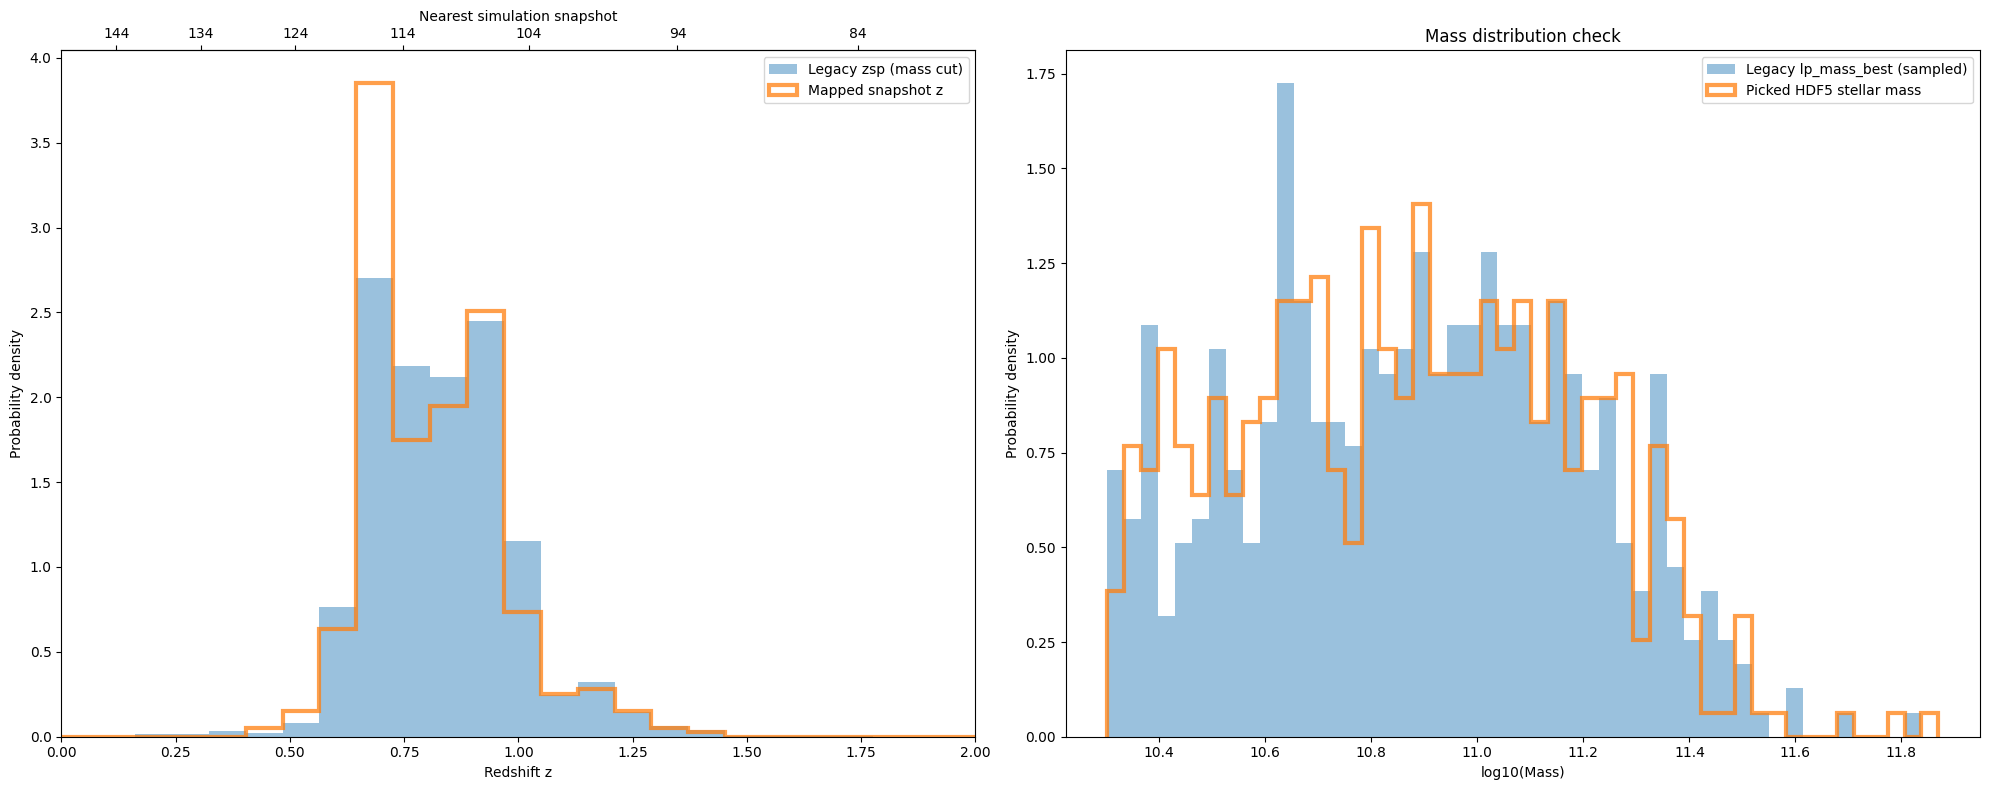

In [4]:
# Legacy zsp sampling + snapshot assignment + mass-matched unique ID picking
import os
import numpy as np
import matplotlib.pyplot as plt
import h5py
from astropy.io import fits

# ---- Inputs ----
legacy_fits = '/mnt/home/glorenzon/output/legacdr3-cosmos2020.fits'
h5_hist = '/mnt/home/glorenzon/output/caesar_sfh/full_simba100_histories_z0_nall.hdf5'
out_fits = '/mnt/home/glorenzon/output/quenching_times/legacy_zsp_sampled_snapshots_with_ids.fits'
mass_threshold = np.log10(2.0e10)   # legacy catalog stores log mass
mass_threshold_linear = 2.0e10      # HDF5 mass history is linear mass
mass_match_sigma_dex = 0.08         # smaller => tighter mass matching
n_draw = 489
snap_min, snap_max = 44, 151

# SIMBA snap->z map (file stores scale factor a; z = 1/a - 1)
snap_map_file = '/mnt/home/glorenzon/output/txt/convert_snap_z_factors/zsnap_map_caesar_box100.txt'

# ---- Read legacy table and mass-cut ----
with fits.open(legacy_fits) as hdul:
    data = hdul[1].data
    name_map = {c.lower(): c for c in hdul[1].columns.names}

if 'zsp' not in name_map:
    raise KeyError('zsp column not found in Legacy FITS.')
if 'lp_mass_best' not in name_map:
    raise KeyError('lp_mass_best column not found in Legacy FITS.')

zsp_col = name_map['zsp']
mass_col = name_map['lp_mass_best']

zsp_all = np.asarray(data[zsp_col], dtype=float)
mass_all = np.asarray(data[mass_col], dtype=float)
mask = np.isfinite(zsp_all) & np.isfinite(mass_all) & (mass_all > mass_threshold) & (zsp_all > 0)
idx = np.where(mask)[0]
if len(idx) == 0:
    raise RuntimeError('No Legacy galaxies pass lp_mass_best > log10(2e10) with finite zsp.')

zsp_sel = zsp_all[idx]
mass_sel = mass_all[idx]

# ---- Draw redshifts+mass from Legacy distribution ----
if n_draw is None:
    n_draw = len(zsp_sel)
rng = np.random.default_rng(42)
draw_idx = rng.choice(np.arange(len(zsp_sel)), size=n_draw, replace=True)
zsp_draw = zsp_sel[draw_idx]
mass_draw = mass_sel[draw_idx]  # log10 mass

# ---- Snapshot mapping from sampled redshift ----
a_map = np.loadtxt(snap_map_file)
z_map = 1.0 / a_map - 1.0
snap_all = np.arange(len(z_map), dtype=int)
snap_mask = (snap_all >= snap_min) & (snap_all <= snap_max)
snap_use = snap_all[snap_mask]
z_use = z_map[snap_mask]

snap_pick = np.empty(len(zsp_draw), dtype=np.int32)
z_snap_pick = np.empty(len(zsp_draw), dtype=float)
for i, z in enumerate(zsp_draw):
    j = int(np.argmin(np.abs(z_use - z)))
    snap_pick[i] = int(snap_use[j])
    z_snap_pick[i] = float(z_use[j])

# ---- Load ID and mass history arrays from HDF5 ----
with h5py.File(h5_hist, 'r') as f:
    if 'metadata/galaxy_ids' not in f:
        raise KeyError('metadata/galaxy_ids not found in history HDF5.')
    galaxy_ids_hist = np.asarray(f['metadata/galaxy_ids'][:], dtype=np.int64)

    if 'properties/GroupID' not in f:
        raise KeyError('properties/GroupID not found in history HDF5.')
    if 'properties/masses.stellar' not in f:
        raise KeyError('properties/masses.stellar not found in history HDF5.')
    if 'redshift/Redshift' not in f:
        raise KeyError('redshift/Redshift not found in history HDF5.')

    id_hist_raw = np.asarray(f['properties/GroupID'][:])
    mass_hist_raw = np.asarray(f['properties/masses.stellar'][:], dtype=float)
    z_hist = np.asarray(f['redshift/Redshift'][:], dtype=float)

n_gal = len(galaxy_ids_hist)
n_snap_hist = len(z_hist)

# Normalize orientation to (n_gal, n_snap_hist): rows=galaxies, cols=snapshots
if id_hist_raw.shape == (n_gal, n_snap_hist):
    id_hist = id_hist_raw
elif id_hist_raw.shape == (n_snap_hist, n_gal):
    id_hist = id_hist_raw.T
else:
    raise ValueError(f'Unexpected GroupID shape {id_hist_raw.shape}, expected {(n_gal, n_snap_hist)} or {(n_snap_hist, n_gal)}')

if mass_hist_raw.shape == (n_gal, n_snap_hist):
    mass_hist = mass_hist_raw
elif mass_hist_raw.shape == (n_snap_hist, n_gal):
    mass_hist = mass_hist_raw.T
else:
    raise ValueError(f'Unexpected masses.stellar shape {mass_hist_raw.shape}, expected {(n_gal, n_snap_hist)} or {(n_snap_hist, n_gal)}')

# Map each history snapshot-column to nearest SIMBA snapshot number
snap_per_hist_col = np.array([snap_use[int(np.argmin(np.abs(z_use - z)))] for z in z_hist], dtype=int)
col_by_snap = {int(s): int(i) for i, s in enumerate(snap_per_hist_col)}

# ---- Pick IDs snapshot-by-snapshot with mass matching + unique original galaxy IDs ----
id_at_selected_snap = np.full(n_draw, -1, dtype=np.int64)
picked_mass_at_snap = np.full(n_draw, np.nan, dtype=float)
orig_galaxy_id_used = np.full(n_draw, -1, dtype=np.int64)
used_orig_ids = set()

for snap in np.unique(snap_pick):
    rows = np.where(snap_pick == snap)[0]
    col = col_by_snap.get(int(snap), None)
    if col is None:
        continue

    ids_col = np.asarray(id_hist[:, col])
    mass_col = np.asarray(mass_hist[:, col], dtype=float)
    orig_ids_col = np.asarray(galaxy_ids_hist, dtype=np.int64)

    valid = np.isfinite(mass_col) & (mass_col > mass_threshold_linear) & np.isfinite(ids_col)
    candidate_ids = ids_col[valid].astype(np.int64)
    candidate_mass = mass_col[valid]
    candidate_orig_ids = orig_ids_col[valid]
    if len(candidate_ids) == 0:
        continue

    candidate_logm = np.log10(candidate_mass)

    # random row order avoids systematic bias when uniqueness constraint is active
    rows_order = rng.permutation(rows)
    for rr in rows_order:
        m_targ = mass_draw[rr]
        # enforce global uniqueness by original z=0 galaxy id
        avail = np.array([oid not in used_orig_ids for oid in candidate_orig_ids], dtype=bool)
        if not np.any(avail):
            continue

        dm = candidate_logm - m_targ
        w = np.exp(-0.5 * (dm / mass_match_sigma_dex) ** 2) * avail.astype(float)
        wsum = np.sum(w)
        if not np.isfinite(wsum) or wsum <= 0:
            avail_idx = np.where(avail)[0]
            pick = int(rng.choice(avail_idx))
        else:
            w = w / wsum
            pick = int(rng.choice(np.arange(len(candidate_ids)), p=w))

        id_at_selected_snap[rr] = candidate_ids[pick]
        picked_mass_at_snap[rr] = candidate_mass[pick]
        orig_galaxy_id_used[rr] = candidate_orig_ids[pick]
        used_orig_ids.add(int(candidate_orig_ids[pick]))

# ---- Save FITS ----
os.makedirs(os.path.dirname(out_fits), exist_ok=True)
cols_out = [
    fits.Column(name='ZSP', array=np.asarray(zsp_draw, dtype=float), format='D'),
    fits.Column(name='LP_BEST_MASS', array=np.asarray(mass_draw, dtype=float), format='D'),
    fits.Column(name='SNAP_SELECTED', array=snap_pick, format='J'),
    fits.Column(name='SNAP_Z', array=np.asarray(z_snap_pick, dtype=float), format='D'),
    fits.Column(name='ORIG_GALAXY_ID', array=np.asarray(orig_galaxy_id_used, dtype=np.int64), format='K'),
    fits.Column(name='ID_AT_SELECTED_SNAP', array=np.asarray(id_at_selected_snap, dtype=np.int64), format='K'),
    fits.Column(name='MSTAR_AT_SELECTED_SNAP', array=np.asarray(picked_mass_at_snap, dtype=float), format='D'),
]
hdu = fits.BinTableHDU.from_columns(cols_out, name='LEGACY_SAMPLE')
hdu.header['LMASSMIN'] = float(mass_threshold)
hdu.header['MSTMIN'] = float(mass_threshold_linear)
hdu.header['MSIGDEX'] = float(mass_match_sigma_dex)
hdu.header['NDRAW'] = int(n_draw)
hdu.header['SNPMIN'] = int(snap_min)
hdu.header['SNPMAX'] = int(snap_max)
hdu.header['IDHIST'] = 'properties/GroupID'
fits.HDUList([fits.PrimaryHDU(), hdu]).writeto(out_fits, overwrite=True)

print('Legacy input:', legacy_fits)
print('History HDF5:', h5_hist)
print('Saved FITS:', out_fits)
print('Rows saved:', n_draw)
print('Valid ID_AT_SELECTED_SNAP:', np.sum(id_at_selected_snap >= 0))
print('Unique ORIG_GALAXY_ID used:', len(np.unique(orig_galaxy_id_used[orig_galaxy_id_used >= 0])))

# ---- Plots ----
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# (1) Redshift distribution + top snapshot axis
z_plot_min = float(min(np.nanmin(zsp_sel), np.nanmin(z_snap_pick), np.nanmin(z_use)))
z_plot_max = float(max(np.nanmax(zsp_sel), np.nanmax(z_snap_pick), np.nanmax(z_use)))
z_bins = np.linspace(z_plot_min, z_plot_max, 60)
ax = axes[0]
ax.hist(zsp_sel, bins=z_bins, alpha=0.45, density=True, label='Legacy zsp (mass cut)')
ax.hist(z_snap_pick, bins=z_bins, alpha=0.75, density=True, label='Mapped snapshot z', histtype='step', lw=3)
ax.set_xlabel('Redshift z')
ax.set_ylabel('Probability density')
ax.set_xlim(0, 2)
ax.legend(loc='upper right')

z_sorted = z_use[::-1]
snap_sorted = snap_use[::-1]

def z_to_snap(z):
    z = np.asarray(z, dtype=float)
    return np.interp(z, z_sorted, snap_sorted)

def snap_to_z(s):
    s = np.asarray(s, dtype=float)
    return np.interp(s, snap_use, z_use)

secax = ax.secondary_xaxis('top', functions=(z_to_snap, snap_to_z))
secax.set_xlabel('Nearest simulation snapshot')
secax.set_xticks(np.arange(snap_min, snap_max + 1, 10))

# (2) Mass distributions
axm = axes[1]
valid_m = np.isfinite(picked_mass_at_snap) & (picked_mass_at_snap > 0)
if np.any(valid_m):
    picked_logm = np.log10(picked_mass_at_snap[valid_m])
    mmin = float(min(np.nanmin(mass_draw), np.nanmin(picked_logm)))
    mmax = float(max(np.nanmax(mass_draw), np.nanmax(picked_logm)))
else:
    picked_logm = np.array([])
    mmin = float(np.nanmin(mass_draw))
    mmax = float(np.nanmax(mass_draw))

mass_bins = np.linspace(mmin, mmax, 50)
axm.hist(mass_draw, bins=mass_bins, alpha=0.45, density=True, label='Legacy lp_mass_best (sampled)')
if picked_logm.size > 0:
    axm.hist(picked_logm, bins=mass_bins, alpha=0.75, density=True, histtype='step', lw=3, label='Picked HDF5 stellar mass')
axm.set_xlabel('log10(Mass)')
axm.set_ylabel('Probability density')
axm.set_title('Mass distribution check')
axm.legend(loc='upper right')

plt.tight_layout()
plt.show()